In [32]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# Balancing / Resampling Imports
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# --- DOWNLOAD-BLOCK ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# ==========================================
# 1. PREPROCESSING CONFIGURATIONS & MAPS
# ==========================================
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    '-', "''", "'",
    'year', 'period', 'quarter', 'today', 'first', 'end', 'finnish', 'finland',
    'helsinki', 'hel', 'nokia', 'corporate', 'corporation', 'oyj', 'oy', 'omx', 'group', 'company',
    'said', 'also', 'include', 'including', 'accord', 'according', 'use', 'per', 'part', 'would',
    'base', 'provide'
}

PRESERVED_WORDS = {
    'below', 'but', 'down', 'few', 'more', 'no', 'nor',
    'not', 'only', 'over', 'should', 'up',
}

english_defaults = set(stopwords.words('english'))
CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

lemmatizer = WordNetLemmatizer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

CURRENCIES = r"eur|usd|gbp|jpy|chf|sek|eek"

FINANCIAL_CLEANUP = [
    (re.compile(r"\bus\s*\$", re.I), "usd"),
    (re.compile(r"\beuros?(?=\d)", re.I), "eur "),
    (re.compile(r"\beuros?\b", re.I), "eur"),
    (re.compile(r"\ber\b", re.I), "eur"),
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"\b(\d+\.?\d*)\s*us\s*million\b", re.I), r"\1mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*us\s*m\b", re.I), r"\1mn"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)", re.I), r"\1pct"),
    (re.compile(r"\bsek\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(rf"\b({CURRENCIES})\s*(\d+\.?\d*)\s*\bm\b", re.I), r"\1\2mn"),
    (re.compile(rf"\b(\d+\.?\d*)\s*\bm\s*({CURRENCIES})\b", re.I), r"\2\1mn"),
    (re.compile(rf"\b({CURRENCIES})\s*(\d+\.?\d*)\s*m\b", re.I), r"\1\2mn"),
    (re.compile(r"({CURRENCIES})\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(rf"({CURRENCIES})\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(rf"([-+]?\d+\.?\d*)\s*({CURRENCIES})(?!\d)", re.I), r"\2\1"),
    (re.compile(rf"\b(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*({CURRENCIES})\b", re.I), r"\3\1\2"),
    (re.compile(rf"({CURRENCIES})(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d|:)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"\s+"), " "), (re.compile(r"\s*'(\w+)"), ""),
    #(re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)(?<!\d\.)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}:{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)
    return text

def _normalize_text_pipeline(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)
    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)
    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)
    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

# ==========================================
# 2. LEMMATIZATION PREPROCESSING STRATEGIES
# ==========================================
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    lemmatized_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            lemmatized_tokens.append(lemma)
    return " ".join(lemmatized_tokens).strip()

def preprocess_masked(text):
    text = _normalize_text_pipeline(text)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE] ', text)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek|eek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT] ', text)
    text = re.sub(r'\b\d{4}:\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{4}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME] ', text)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT] ', text)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER] ', text)

    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    mask_placeholders = {
        '[PHONE]', '[MONEY]', '[PERCENT]',
        '[DATE]', '[TIME]', '[MEASUREMENT]', '[NUMBER]'
    }
    processed_tokens = []
    for word, tag in tagged_tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        else:
            word_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=word_pos)
            if lemma not in CUSTOM_STOPWORDS:
                processed_tokens.append(lemma)
    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

def preprocess_standard_optimized(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()

def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()


# ==========================================
# 3. PYTORCH MODEL WRAPPER (FIXED FOR COMPLIANCE)
# ==========================================
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_classes=3, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=5, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.n_classes = n_classes
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state

    def fit(self, X, y):
        if torch.backends.mps.is_available():
            self.device_ = torch.device("mps")
        elif torch.cuda.is_available():
            self.device_ = torch.device("cuda")
        else:
            self.device_ = torch.device("cpu")

        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu': layers.append(nn.ReLU())
            elif self.activation == 'tanh': layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model_ = nn.Sequential(*layers).to(self.device_)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model_.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model_.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 3

        for epoch in range(self.max_iter):
            self.model_.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device_), batch_y.to(self.device_)
                optimizer.zero_grad()
                outputs = self.model_(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model_.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device_), batch_y.to(self.device_)
                        outputs = self.model_(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience: break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device_)
        self.model_.eval()
        with torch.no_grad():
            outputs = self.model_(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

# ==========================================
# 4. MAIN EVALUATION LOOP
# ==========================================
TARGET_COL = "sentiment"
try:
    df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])
except FileNotFoundError:
    dummy_data = {
        "sentence": ["Nokia signs 3-year deal with alternative eur10m networks.", "The financial group corporate profit fell by 50pct down.", "The company oyj expects sales growth over next period."] * 50,
        "sentiment": ["positive", "negative", "neutral"] * 50
    }
    df = pd.DataFrame(dummy_data)

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])

print("Applying text preprocessing routines to dataset...")
df["sentence"] = df["sentence"].drop_duplicates(keep="first")
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_standard_numbers"] = df["sentence"].apply(preprocess_standard_optimized)
df['prep_masked'] = df['sentence'].apply(preprocess_masked)
df = df.drop_duplicates(subset=['prep_masked'], keep="first")

# Focused N-Gram ranges to prevent combinatorial execution lock
ngram_ranges = [(1, 1), (1, 2), (1, 3), (1,4)]

# FIXED: Replaced "preprocess_standard_optimized" with "prep_standard_numbers" to match df columns
strategies = ["prep_standard", "prep_full", "prep_masked", "prep_standard_numbers"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

samplers = {
    "None (Imbalanced)": None,
    "SMOTE (Oversampling)": SMOTE(random_state=42),
    "SMOTETomek (Combined)": SMOTETomek(random_state=42),
    "Tomek (Undersampling)": TomekLinks()
}

results = []
models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Updated)": PyTorchMLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate_init=0.005,
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
}

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    for ngram in ngram_ranges:
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)

        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)

        for sampler_name, sampler_instance in samplers.items():

            if sampler_instance is not None:
                current_sampler_bow = clone(sampler_instance)
                current_sampler_tfidf = clone(sampler_instance)
                X_train_bow, y_train_resampled_bow = current_sampler_bow.fit_resample(X_train_bow_raw, y_train)
                X_train_tfidf, y_train_resampled_tfidf = current_sampler_tfidf.fit_resample(X_train_tfidf_raw, y_train)

            else:
                X_train_bow, y_train_resampled_bow = X_train_bow_raw, y_train
                X_train_tfidf, y_train_resampled_tfidf = X_train_tfidf_raw, y_train

            final_feature_size_bow = X_train_bow.shape[1]
            final_feature_size_tfidf = X_train_tfidf.shape[1]

            for model_name, original_model_instance in models.items():
                # BoW Fit Sequence
                model_instance = clone(original_model_instance)
                model_instance.fit(X_train_bow, y_train_resampled_bow)
                y_pred_bow = model_instance.predict(X_test_bow)
                results.append({
                    "Model": model_name, "Strategy": strategy, "Sampling Strategy": sampler_name,
                    "Vectorizer": "BoW", "N-Gram": str(ngram), "Feature Size": final_feature_size_bow,
                    "Accuracy": accuracy_score(y_test, y_pred_bow), "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
                })

                # TF-IDF Fit Sequence
                model_instance = clone(original_model_instance)
                model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
                y_pred_tfidf = model_instance.predict(X_test_tfidf)
                results.append({
                    "Model": model_name, "Strategy": strategy, "Sampling Strategy": sampler_name,
                    "Vectorizer": "TF-IDF", "N-Gram": str(ngram), "Feature Size": final_feature_size_tfidf,
                    "Accuracy": accuracy_score(y_test, y_pred_tfidf), "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
                })

results_df = pd.DataFrame(results)

# Clean up categorization assignments cleanly
results_df['Strategy'] = pd.Categorical(
    results_df['Strategy'],
    categories=['prep_standard', 'prep_full', 'prep_masked', 'prep_standard_numbers'],
    ordered=True
)

big_matrix = pd.pivot_table(
    results_df, values='Macro-F1',
    index=['Model', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Feature Size'],
    columns=['Strategy'],
    aggfunc='max'
)

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")
results_df.to_csv("Master_performance_matrix.csv", sep=";")


Applying text preprocessing routines to dataset...
---> Processing Strategy: PREP_STANDARD
---> Processing Strategy: PREP_FULL
---> Processing Strategy: PREP_MASKED
---> Processing Strategy: PREP_STANDARD_NUMBERS

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                                                             prep_standard  \
Model          Sampling Strategy     Vectorizer N-Gram Feature Size                  
FFNN (Updated) None (Imbalanced)     BoW        (1, 1) 6723                 0.6826   
                                                       7293                    NaN   
                                                       7575                    NaN   
                                                       9411                    NaN   
                                                (1, 2) 36004                0.6842   
                                                       36340                   NaN   
     

In [6]:
# 1. Ensure 'Strategy' is treated as a category to prevent misalignment
results_df['Strategy'] = pd.Categorical(
    results_df['Strategy'],
    categories=['prep_standard', 'prep_full', 'prep_masked'],
    ordered=True
)

results_df.to_csv("Master_performance_matrix.csv", sep=";")

# 2. Use pivot_table with a fixed aggregation function (e.g., 'max')
# This forces the table to pick the best score if duplicates exist,
# and handles missing strategy entries more gracefully.
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Feature Size'],
    columns=['Strategy'],
    aggfunc='max'
)

# 3. Fill remaining NaNs with 0 (or drop them) if a strategy combination truly doesn't exist
big_matrix = big_matrix.fillna(0)

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")



========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                                                             prep_standard  \
Model          Sampling Strategy     Vectorizer N-Gram Feature Size                  
FFNN (Updated) None (Imbalanced)     BoW        (1, 1) 6713                 0.6597   
                                                       7287                 0.0000   
                                                       9372                 0.0000   
                                                (1, 2) 35864                0.6710   
                                                       36179                0.0000   
...                                                                            ...   
Naive Bayes    Tomek (Undersampling) TF-IDF     (1, 3) 68197                0.0000   
                                                       75857                0.0000   
                                              

/var/folders/r7/0ljgth4j3jg083688wfzcpww0000gn/T/ipykernel_67128/2851979190.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  results_df['Strategy'] = pd.Categorical(


In [7]:
import pprint
import csv
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
#pprint.pprint(df["sentence"])
print(df.columns)
print(df.shape)
df.to_csv(
    "complete_df_3_strategies.csv",
    index=True,
    sep=";",
    quoting=csv.QUOTE_NONNUMERIC  # This wraps all text columns in ""
)
#pprint.pprint(df.iloc[[23, 4739, 3857, 2184, 2175, 2080]])
#pprint.pprint(df.iloc[[2080, 4739]])




Index(['sentence', 'sentiment', 'prep_standard', 'prep_full',
       'prep_standard_numbers', 'prep_masked'],
      dtype='str')
(4752, 6)


In [16]:
# creating table for section 2
import pandas as pd

# 1. Select the rows and columns
selected_df = df.iloc[[2080, 4739]][['sentence', 'prep_standard', 'prep_standard_numbers', 'prep_full', 'prep_masked']].copy()
selected_df.columns = ['Original Sentence', 'Strategy 1', 'Strategy 2', 'Strategy 3', 'Strategy 4']

# 2. Process Example 1
ex1 = selected_df.iloc[[0]].T.reset_index()
ex1.columns = ['Feature', 'Example 1']

# 3. Process Example 2
ex2 = selected_df.iloc[[1]].T.reset_index()
ex2.columns = ['Feature', 'Example 2']

# 4. Generate LaTeX components manually to stack them with a divider
latex_table_ex1 = ex1.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')
latex_table_ex2 = ex2.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')

# Clean up the headers/footers of the inner tables so they merge cleanly
# We strip the tabular environment wrappers from the pandas output
ex1_body = "\n".join(latex_table_ex1.split("\n")[1:-3])
ex2_body = "\n".join(latex_table_ex2.split("\n")[1:-3])

# 5. Construct the final combined LaTeX table
latex_output = r"""
\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
""" + ex1_body + r"""
\midrule
\midrule
""" + ex2_body + r"""
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_output)



\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
\toprule
Feature & Example 1 \\
\midrule
Original Sentence & In 2006 , TeliaSonera net sales were SEK 91 bn , EBITDA was SEK 32.266 bn , net income was SEK 19.28 bn . \\
Strategy 1 & teliasonera net sale sek bn ebitda sek bn net income sek bn \\
Strategy 2 & 2006 teliasonera net sale sek 91 bn ebitda sek 32 266 bn net income sek 19 28 bn \\
Strategy 3 & 2006 , teliasonera net sale eur91bn , ebitda eur32.266bn , net income eur19.28bn . \\
Strategy 4 & [DATE] , teliasonera net sale [MONEY] , ebitda [MONEY] , net income [MONEY] . \\
\midrule
\midrule
\toprule
Feature & Example 2 \\
\midrule
Original Sentence & Nevertheless , the development can not be allowed to ruin the print newspaper , which continues to be Sanoma News ' main medium . \\
Strategy 1 & nevertheless development not allow ruin print newspaper continue sanoma

In [9]:
import pandas as pd
import re

# ==========================================
# 1. FIND COMPLIANT CANDIDATES
# ==========================================
masks = ['\[PHONE\]', '\[MONEY\]', '\[PERCENT\]', '\[DATE\]', '\[TIME\]', '\[MEASUREMENT\]', '\[NUMBER\]']
mask_pattern = '|'.join(masks)
dense_mask_regex = re.compile(rf"({mask_pattern}).*?({mask_pattern})", re.IGNORECASE)

# Filter down to the exact subset conditions requested
filtered_df = df[
    (df['sentence'].str.len() < 100) &
    (df['prep_masked'].str.contains(dense_mask_regex, na=False))
]

# Safeguard check: ensure we actually found at least 2 rows
if len(filtered_df) < 2:
    raise ValueError("Could not find at least two rows matching the length and mask criteria.")

# Pull the top 2 matching rows automatically
selected_df = filtered_df.head(2)[['sentence', 'prep_standard', 'prep_standard_numbers', 'prep_full', 'prep_masked']].copy()
selected_df.columns = ['Original Sentence', 'Strategy 1', 'Strategy 2', 'Strategy 3', 'Strategy 4']

# ==========================================
# 2. GENERATE LATEX ROW BY ROW (SAFE ALTERNATIVE)
# ==========================================
labels = [
    'Original Sentence',
    'Strategy 1 (Standard)',
    'Strategy 2 (Enhanced)',
    'Strategy 3 (Full)',
    'Strategy 4 (Masked)'
]

latex_rows = []
for idx, row in enumerate(selected_df.itertuples(index=False)):
    latex_rows.append(f"\\textbf{{Example {idx + 1}}} & \\\\")
    for label, val in zip(labels, row):
        # Sanitize common raw string anomalies for LaTeX compilation safety
        escaped_val = str(val).replace("$", "\\$").replace("%", "\\%").replace("_", "\\_")
        latex_rows.append(f"{label} & {escaped_val} \\\\")

    # Place a clean divider after the first block
    if idx == 0:
        latex_rows.append("\\midrule")

# Combine rows into a unified, formal booktabs structure
latex_output = f"""\\begin{{table}}[h]
\\centering
\\caption{{Preprocessing Results Stacked Vertically}}
\\label{{tab:preprocessing_stacked_vertical}}
\\small
\\begin{{tabular}}{{lp{{12cm}}}}
\\toprule
\\textbf{{Feature / Pipeline}} & \\textbf{{Processed Text String Baseline}} \\\\
\\midrule
{chr(10).join(latex_rows)}
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

print(latex_output)


\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\small
\begin{tabular}{lp{12cm}}
\toprule
\textbf{Feature / Pipeline} & \textbf{Processed Text String Baseline} \\
\midrule
\textbf{Example 1} & \\
Original Sentence & Commission income increased by 22 \% to EUR 4.4 mn , and lending volume rose by 13.5 \% . \\
Strategy 1 (Standard) & commission income increase eur mn lending volume rise \\
Strategy 2 (Enhanced) & commission income increase 22 eur 4 4 mn lending volume rise 13 5 \\
Strategy 3 (Full) & commission income increase 22pct eur4.4mn lending volume rise 13.5pct \\
Strategy 4 (Masked) & commission income increase [PERCENT] [MONEY] lending volume rise [PERCENT] \\
\midrule
\textbf{Example 2} & \\
Original Sentence & Circulation revenue has increased by 5 \% in Finland and 4 \% in Sweden in 2008 . \\
Strategy 1 (Standard) & circulation revenue increase sweden \\
Strategy 2 (Enhanced) & circulation revenue incre

<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\['
/var/folders/r7/0ljgth4j3jg083688wfzcpww0000gn/T/ipykernel_67128/2702771942.py:7: SyntaxWarning: invalid escape sequence '\['
  masks = ['\[PHONE\]', '\[MONEY\]', '\[PERCENT\]', '\[DATE\]', '\[TIME\]', '\[MEASUREMENT\]', '\[NUMBER\]']
/var/folders/r7/0ljgth4j3jg083688wfzcpww0000gn/T/ipykernel_67128/


--- LOCAL PERFORMANCE WINNER ---
              Model       Strategy      Sampling Strategy Vectorizer  N-Gram  \
147  FFNN (Updated)    prep_masked      None (Imbalanced)     TF-IDF  (1, 2)   
39   FFNN (Updated)  prep_standard   SMOTE (Oversampling)     TF-IDF  (1, 3)   
155  FFNN (Updated)    prep_masked  SMOTETomek (Combined)     TF-IDF  (1, 2)   
159  FFNN (Updated)    prep_masked  Tomek (Undersampling)     TF-IDF  (1, 2)   
160     Naive Bayes    prep_masked      None (Imbalanced)        BoW  (1, 3)   
101     Naive Bayes      prep_full   SMOTE (Oversampling)     TF-IDF  (1, 3)   
105     Naive Bayes      prep_full  SMOTETomek (Combined)     TF-IDF  (1, 3)   
76      Naive Bayes      prep_full  Tomek (Undersampling)        BoW  (1, 1)   

     Macro-F1  
147  0.722870  
39   0.714509  
155  0.710574  
159  0.724481  
160  0.640504  
101  0.647174  
105  0.647174  
76   0.640543  
-----------------------------------

--- GLOBAL PERFORMANCE WINNER ---
Model                       FF

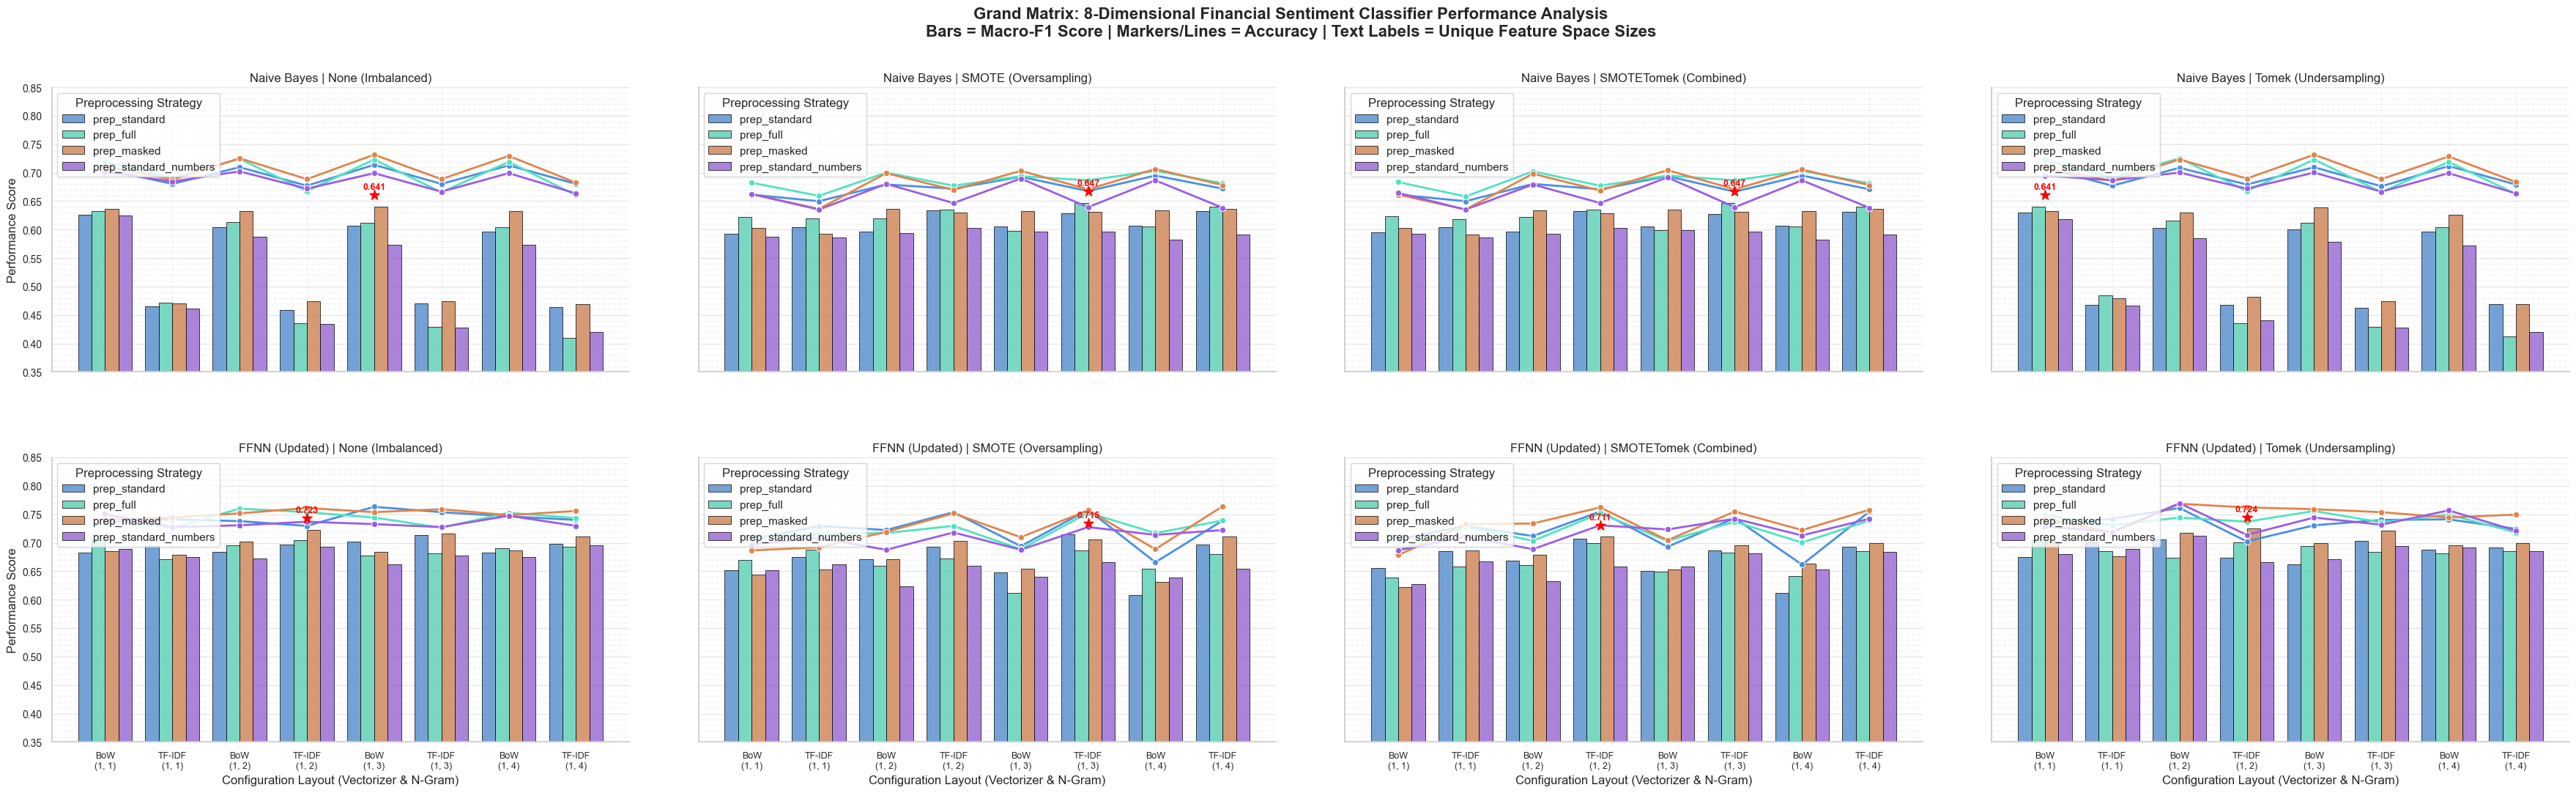

In [19]:
# ==========================================
# 5. ADVANCED MULTIDIMENSIONAL VISUALIZATION (8 DIMENSIONS)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

local_winners = results_df.loc[results_df.groupby(['Model', 'Sampling Strategy'])['Macro-F1'].idxmax()]
print("\n--- LOCAL PERFORMANCE WINNER ---")
print(local_winners[['Model', 'Strategy', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Macro-F1']])
print("-" * 35)

# 2. Identify Global Winner
global_winner = results_df.loc[results_df['Macro-F1'].idxmax()]


print("\n--- GLOBAL PERFORMANCE WINNER ---")
print(global_winner[['Model', 'Strategy', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Macro-F1']])
print("-" * 35)

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# UPDATED: Extended to handle all 4 datasets with distinct hex codes
strategy_colors = {
    'prep_standard': '#4A90E2',          # Soft Blue
    'prep_full': '#50E3C2',              # Mint Green
    'prep_masked': '#E2844A',            # Muted Orange
    'prep_standard_numbers': '#9B5DE5'   # Vibrant Deep Purple
}
strategy_order = ['prep_standard', 'prep_full', 'prep_masked', 'prep_standard_numbers']

print("\nGenerating 8D publication-quality performance grid...")

# Prepare a combined label for X-axis to group Vectorizer + N-Gram cleanly
# This elegantly handles Dim 3 (N-Gram) and Dim 6 (Vectorizer) side-by-side
results_df["Vec_N-Gram"] = results_df["Vectorizer"] + "\n" + results_df["N-Gram"]

# Set dynamic boundaries to maximize visible differences
min_y = min(results_df["Macro-F1"].min(), results_df["Accuracy"].min())
max_y = max(results_df["Macro-F1"].max(), results_df["Accuracy"].max())
y_lower_bound = max(0.0, float(np.floor(min_y * 20) / 20) - 0.05)
y_upper_bound = min(1.0, float(np.ceil(max_y * 20) / 20) + 0.05)

# Initialize FactorPlot Grid
# Dim 1 (Model) -> Rows | Dim 2 (Sampling Strategy) -> Columns
g = sns.FacetGrid(
    data=results_df,
    row="Model",
    col="Sampling Strategy",
    height=5.5,  # Slightly expanded height to give the 4th bar breathing room
    aspect=1.6,
    sharex=True,
    sharey=True
)

# Function to draw the hybrid metrics + label feature sizes on each subplot
def draw_multidimensional_plots(data, **kwargs):
    ax = plt.gca()

    # 1. Plot Bars and Lines tracking all 4 pipeline variations
    sns.barplot(data=data, x="Vec_N-Gram", y="Macro-F1", hue="Strategy",
                hue_order=strategy_order, palette=strategy_colors,
                edgecolor="black", linewidth=0.6, alpha=0.85, ax=ax)

    sns.lineplot(data=data, x="Vec_N-Gram", y="Accuracy", hue="Strategy",
                 hue_order=strategy_order, palette=strategy_colors,
                 marker="o", markersize=6, linewidth=2, legend=False, ax=ax)

    # 2. Highlight Local Winner
    best_row = data.loc[data['Macro-F1'].idxmax()]

    # Draw a star highlight marker on the winner
    x_coords = data['Vec_N-Gram'].unique().tolist()
    x_idx = x_coords.index(best_row['Vec_N-Gram'])

    ax.scatter(x_idx, best_row['Macro-F1'] + 0.02, color='red', marker='*', s=100, zorder=5)

    # 3. Add Annotations
    ax.text(x_idx, best_row['Macro-F1'] + 0.03, f"{best_row['Macro-F1']:.3f}",
            ha='center', fontsize=9, color='red', weight='bold')

    # # Dim 7 (Feature Size Matrix Labels)
    # unique_feats = data.drop_duplicates(subset=["Vec_N-Gram"])
    # for idx, row_val in unique_feats.iterrows():
    #     x_pos = unique_feats['Vec_N-Gram'].tolist().index(row_val['Vec_N-Gram'])
    #     ax.text(x_pos, y_lower_bound + 0.01, f"Feat:\n{int(row_val['Feature Size'])}",
    #             ha='center', va='bottom', fontsize=7, color='#555555',
    #             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Map our custom drawing function across the FacetGrid matrix
g.map_dataframe(draw_multidimensional_plots)

# Refine grid architecture layouts
g.set_axis_labels("Configuration Layout (Vectorizer & N-Gram)", "Performance Score")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Fine-tune tick formatting and grid visibility parameters
for ax in g.axes.flat:
    ax.set_ylim(y_lower_bound, y_upper_bound)

    # Setup precision tick lines to easily read subtle discrepancies
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
    ax.yaxis.grid(True, which='major', linestyle="-", alpha=0.5)
    ax.yaxis.grid(True, which='minor', linestyle="--", alpha=0.25)
    ax.xaxis.grid(True, linestyle=":", alpha=0.4)

    # Handle Legend cleanup to avoid duplicate entries across windows
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # UPDATED: Sliced at [:4] instead of [:3] to ensure all 4 components display inside the legend
        ax.legend(handles[:4], labels[:4], title="Preprocessing Strategy", loc="upper left", frameon=True)

# Adjust overall margins clean for title placement
g.fig.subplots_adjust(top=0.88, hspace=0.3, wspace=0.12)
g.fig.suptitle(
    "Grand Matrix: 8-Dimensional Financial Sentiment Classifier Performance Analysis\n"
    "Bars = Macro-F1 Score | Markers/Lines = Accuracy | Text Labels = Unique Feature Space Sizes",
    weight="bold"
)

results_df.to_csv("grand_8d_evaluation_matrix.csv", sep=";")
# Export structural matrix graphic asset
plt.savefig("grand_8d_evaluation_matrix.png", dpi=300, bbox_inches='tight')
print("Complete 8D Evaluation Grid tracking all 4 strategies saved as 'grand_8d_evaluation_matrix.png'!")
plt.show()



GENERATING CONFUSION MATRICES FOR TOP PERFORMERS

Re-evaluating best Naive Bayes pipeline...
 -> Strategy: prep_full | N-Gram: (1, 3) | Sampler: SMOTE (Oversampling)
 -> Matrix generated and saved as: 'confusion_matrix_naive_bayes.png'


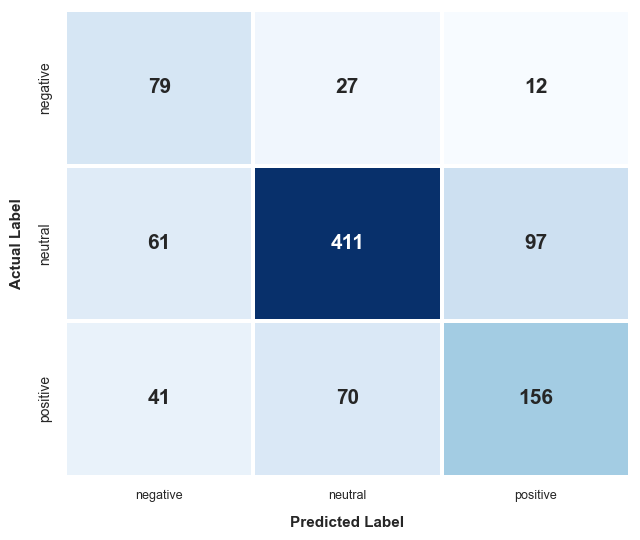


Re-evaluating best FFNN (Updated) pipeline...
 -> Strategy: prep_masked | N-Gram: (1, 2) | Sampler: Tomek (Undersampling)
 -> Matrix generated and saved as: 'confusion_matrix_ffnn_updated.png'


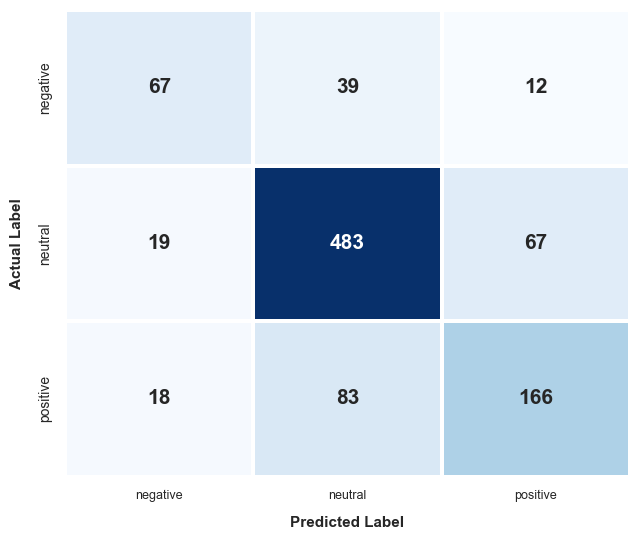

In [33]:
# ==========================================
# 6. DYNAMIC BEST-IN-CLASS CONFUSION MATRICES
# ==========================================
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import ast

print("\n" + "="*50)
print("GENERATING CONFUSION MATRICES FOR TOP PERFORMERS")
print("="*50)

# 1. Identify the top configurations dynamically from your results dataframe
top_models = []
for model_name in ["Naive Bayes", "FFNN (Updated)"]:
    if model_name in results_df['Model'].values:
        # Filter for the specific model, then find the row with the max Macro-F1
        best_row = results_df[results_df['Model'] == model_name].loc[
            results_df[results_df['Model'] == model_name]['Macro-F1'].idxmax()
        ]
        top_models.append(best_row)

# 2. Dictionary to map the string names back to actual sampler objects
sampler_map = {
    "None (Imbalanced)": None,
    "SMOTE (Oversampling)": SMOTE(random_state=42),
    "SMOTETomek (Combined)": SMOTETomek(random_state=42),
    "Tomek (Undersampling)": TomekLinks()
}

custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

for config in top_models:
    model_name = config['Model']
    strategy = config['Strategy']

    # Safely convert the N-Gram string like "(1, 2)" back to an actual tuple
    ngram_str = config['N-Gram']
    ngram = ast.literal_eval(ngram_str) if isinstance(ngram_str, str) else ngram_str

    sampler_name = config['Sampling Strategy']
    sampler = sampler_map.get(sampler_name)

    print(f"\nRe-evaluating best {model_name} pipeline...")
    print(f" -> Strategy: {strategy} | N-Gram: {ngram} | Sampler: {sampler_name}")

    # 3. Prepare the split using the exact identical stratifications
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    # 4. Vectorize enforcing the 5000 feature limit
    if config['Vectorizer'] == 'BoW':
        vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern, max_features=5000)
    else:
        vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern, max_features=5000)

    X_train_vec = vect.fit_transform(X_train_raw)
    X_test_vec = vect.transform(X_test_raw)

    # 5. Apply the specific sampler
    if sampler is not None:
        X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)
    else:
        X_train_res, y_train_res = X_train_vec, y_train

    # 6. Initialize and Train the Model
    if model_name == "Naive Bayes":
        clf = MultinomialNB()
    else:
        # Re-seed PyTorch to guarantee weight initialization matches
        if 'set_reproducible_seeds' in globals():
            set_reproducible_seeds(42)

        # Dynamically inject hyperparams if they were saved to the dataframe, otherwise use defaults
        clf = PyTorchMLPClassifier(
            hidden_layer_sizes=ast.literal_eval(config['Best Hidden Layers']) if 'Best Hidden Layers' in config else (64, 32),
            activation=config.get('Best Activation', 'relu'),
            alpha=float(config.get('Alpha', 0.0001)),
            batch_size=int(config.get('Batch Size', 128)),
            learning_rate_init=float(config.get('Learning Rate Init', 0.001)),
            max_iter=50,
            random_state=42
        )

    clf.fit(X_train_res, y_train_res)
    y_pred = clf.predict(X_test_vec)

    # 7. Generate and Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    f1_macro = config['Macro-F1']

    plt.figure(figsize=(6.5, 5.5))
    ax = plt.gca()

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
        linewidths=1.5, linecolor='white', ax=ax,
        annot_kws={"size": 15, "weight": "bold"}
    )

    #ax.set_title(f"Global Best: {model_name}\n{strategy} | {sampler_name}\n(Macro-F1: {f1_macro:.4f})", weight='bold', fontsize=12, pad=12)
    ax.set_xlabel("Predicted Label", labelpad=10, fontsize=11, weight='bold')
    ax.set_ylabel("Actual Label", labelpad=10, fontsize=11, weight='bold')

    clean_filename = f"confusion_matrix_{model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.tight_layout()
    plt.savefig(clean_filename, dpi=300, bbox_inches='tight')
    print(f" -> Matrix generated and saved as: '{clean_filename}'")
    plt.show()
    plt.close()


In [34]:
# ==========================================
# 5. ADVANCED SEPARATE VISUALIZATIONS (4 DISTINCT PNGs)
# ==========================================
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Identify and print Global Winner
global_winner = results_df.loc[results_df['Macro-F1'].idxmax()]
print("\n--- GLOBAL PERFORMANCE WINNER ---")
print(global_winner[['Model', 'Strategy', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Macro-F1']])
print("-" * 35)

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
})

strategy_colors = {
    'prep_standard': '#4A90E2',          # Soft Blue
    'prep_full': '#50E3C2',              # Mint Green
    'prep_masked': '#E2844A',            # Muted Orange
    'prep_standard_numbers': '#9B5DE5'   # Vibrant Deep Purple
}
strategy_order = ['prep_standard', 'prep_full', 'prep_masked', 'prep_standard_numbers']

# Prepare combined label for X-axis grouping Vectorizer + N-Gram cleanly
results_df["Vec_N-Gram"] = results_df["Vectorizer"] + "\n" + results_df["N-Gram"]

# Set dynamic boundaries globally to keep Y-axes comparable across files
min_y = min(results_df["Macro-F1"].min(), results_df["Accuracy"].min())
max_y = max(results_df["Macro-F1"].max(), results_df["Accuracy"].max())
y_lower_bound = max(0.0, float(np.floor(min_y * 20) / 20) - 0.05)
y_upper_bound = min(1.0, float(np.ceil(max_y * 20) / 20) + 0.05)

# Save raw matrix data
results_df.to_csv("grand_8d_evaluation_matrix.csv", sep=";")

# Iterate over unique combinations to generate 4 standalone plots
unique_models = results_df["Model"].unique()
unique_samplings = results_df["Sampling Strategy"].unique()

print("\nGenerating 4 separate publication-quality plots...")
latex_captions = []

for model in unique_models:
    for sampling in unique_samplings:
        # Filter dataframe for the current combination split
        subset_data = results_df[(results_df["Model"] == model) & (results_df["Sampling Strategy"] == sampling)].copy()

        if subset_data.empty:
            continue

        # Create unique, clean file names
        clean_model = model.lower().replace(" ", "_").replace("(", "").replace(")", "")
        clean_sampling = sampling.lower().replace(" ", "_").replace("+", "plus")
        filename = f"matrix_{clean_model}_{clean_sampling}.png"

        # Initialize standalone figure canvas
        plt.figure(figsize=(8.5, 5.5))
        ax = plt.gca()

        # 1. Plot Bars (Macro-F1) and Lines (Accuracy)
        sns.barplot(data=subset_data, x="Vec_N-Gram", y="Macro-F1", hue="Strategy",
                    hue_order=strategy_order, palette=strategy_colors,
                    edgecolor="black", linewidth=0.6, alpha=0.85, ax=ax)

        sns.lineplot(data=subset_data, x="Vec_N-Gram", y="Accuracy", hue="Strategy",
                     hue_order=strategy_order, palette=strategy_colors,
                     marker="o", markersize=6, linewidth=2, legend=False, ax=ax)

        # 2. Identify and Highlight Local Winner for this specific plot
        # Reset index to guarantee reliable positional indexing for the star marker
        subset_data = subset_data.reset_index(drop=True)
        best_idx = subset_data['Macro-F1'].idxmax()
        best_row = subset_data.loc[best_idx]

        unique_x_labels = subset_data['Vec_N-Gram'].unique().tolist()
        x_pos = unique_x_labels.index(best_row['Vec_N-Gram'])

        # Draw star marker and text annotation above the winning configuration group
        ax.scatter(x_pos, best_row['Macro-F1'] + 0.015, color='red', marker='*', s=120, zorder=5)
        ax.text(x_pos, best_row['Macro-F1'] + 0.025, f"{best_row['Macro-F1']:.3f}",
                ha='center', fontsize=9.5, color='red', weight='bold')

        # 3. Design Polish & Tick Adjustments
        #ax.set_title(f"Performance Metrics: {model} ({sampling})\nBars = Macro-F1 | Lines = Accuracy", weight="bold", pad=12)
        ax.set_xlabel("Configuration Layout (Vectorizer & N-Gram)", labelpad=10)
        ax.set_ylabel("Performance Score", labelpad=10)
        ax.set_ylim(y_lower_bound, y_upper_bound)

        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
        ax.yaxis.grid(True, which='major', linestyle="-", alpha=0.5)
        ax.yaxis.grid(True, which='minor', linestyle="--", alpha=0.25)
        ax.xaxis.grid(True, linestyle=":", alpha=0.4)

        # 4. Clean Legend setup
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles[:4], labels[:4], title="Preprocessing Strategy", loc="upper left", frameon=True)

        # Save figure cleanly with snug borders
        plt.savefig(filename, dpi=300, bbox_inches='tight')

        # APPEND: Save the title info to our list for LaTeX
        latex_captions.append({
            'file': filename,
            'title': f"Performance Metrics: {model} ({sampling})",
            'desc': "Bars = Macro-F1 | Lines = Accuracy"
        })


        print(f" -> Saved: {filename}")
        plt.close()

with open("figure_titles.tex", "w") as f:
    for item in latex_captions:
        f.write(r"\begin{figure}[htbp]" + "\n")
        f.write(r"    \centering" + "\n")
        f.write(f"    \\includegraphics[width=0.8\\textwidth]{{{item['file']}}}" + "\n")
        f.write(f"    \\caption{{{item['title']}: {item['desc']}}}" + "\n")
        f.write(r"    \label{fig:" + item['file'].replace('.png', '') + "}" + "\n")
        f.write(r"\end{figure}" + "\n\n")

print("\nLaTeX figure code generated and saved to 'figure_titles.tex'!")

print("\nAll 4 isolated metrics plots have been successfully generated!")



--- GLOBAL PERFORMANCE WINNER ---
Model                       FFNN (Updated)
Strategy                       prep_masked
Sampling Strategy    Tomek (Undersampling)
Vectorizer                          TF-IDF
N-Gram                              (1, 2)
Macro-F1                          0.724481
Name: 159, dtype: object
-----------------------------------

Generating 4 separate publication-quality plots...
 -> Saved: matrix_naive_bayes_none_(imbalanced).png
 -> Saved: matrix_naive_bayes_smote_(oversampling).png
 -> Saved: matrix_naive_bayes_smotetomek_(combined).png
 -> Saved: matrix_naive_bayes_tomek_(undersampling).png
 -> Saved: matrix_ffnn_updated_none_(imbalanced).png
 -> Saved: matrix_ffnn_updated_smote_(oversampling).png
 -> Saved: matrix_ffnn_updated_smotetomek_(combined).png
 -> Saved: matrix_ffnn_updated_tomek_(undersampling).png

LaTeX figure code generated and saved to 'figure_titles.tex'!

All 4 isolated metrics plots have been successfully generated!


Running targeted pipeline evaluations for multi-metric reporting (Sampler: SMOTETomek)...

================================ ADVANCED EVALUATION METRICS REPORT ================================
    Configuration    Strategy Accuracy Precision Recall Macro-F1
Naive Bayes + BoW   prep_full   0.6814    0.6144 0.6227   0.6151
Naive Bayes + BoW prep_masked   0.6557    0.5843 0.6112   0.5908
    FFNN + TF-IDF   prep_full   0.7134    0.6655 0.6787   0.6717
    FFNN + TF-IDF prep_masked   0.7175    0.6949 0.6914   0.6879
Standalone matrix image saved successfully: best_cm_smotetomek_naive_bayes_bow.png


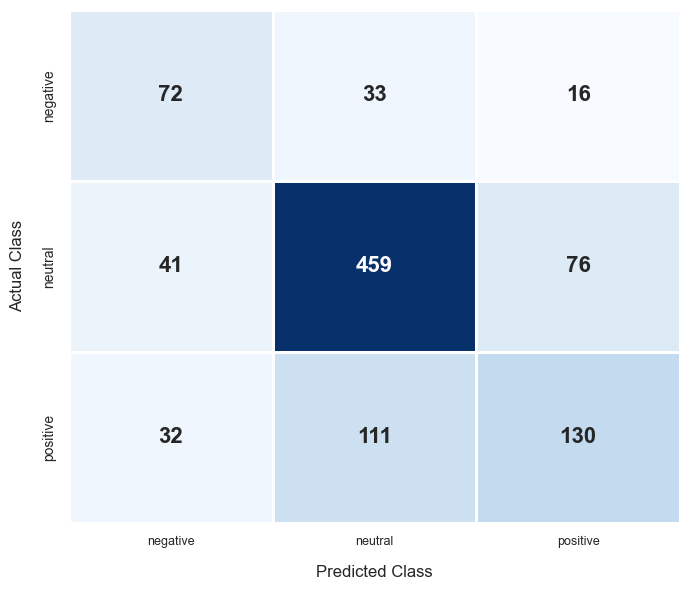

Standalone matrix image saved successfully: best_cm_smotetomek_ffnn_tf-idf.png


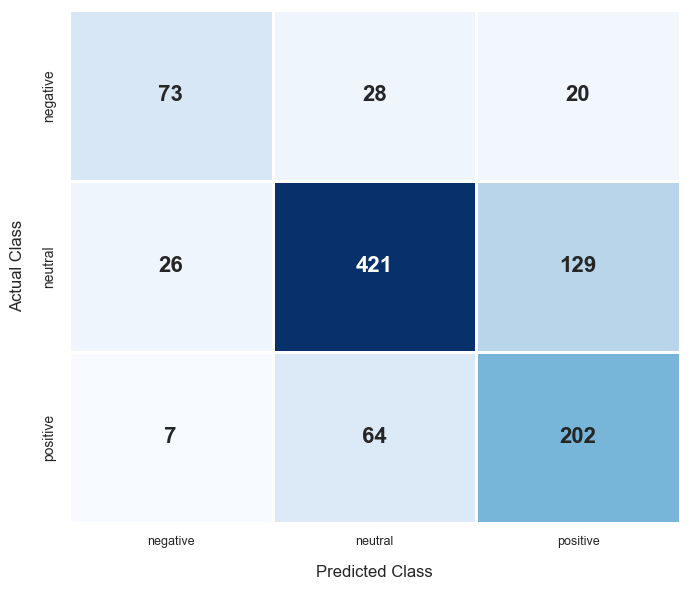

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone

# Import the target combination sampler
from imblearn.combine import SMOTETomek

# ==========================================
# 5. ADVANCED TARGETED HEAD-TO-HEAD REPORT
# ==========================================

# Define target configurations
target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 1)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 2)}
]

strategies = ["prep_standard", "prep_full", "prep_masked", "prep_standard_numbers"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

detailed_results = []
confusion_matrices = {} # Stores matrices for visual reporting

# Initialize SMOTETomek sampler instance
sampler = SMOTETomek(random_state=42)

print("Running targeted pipeline evaluations for multi-metric reporting (Sampler: SMOTETomek)...")

for config in target_configs:
    n_classes = len(np.unique(y_train_res))

            # Initialize Model
    if config["Model Name"] == "FFNN":
        if 'set_reproducible_seeds' in globals():
            set_reproducible_seeds(42)

        # Pass n_classes to the model so the output layer matches the data
        clf = config["Model_Init"](n_classes=n_classes)
    else:
        clf = clone(config["Model"])

    clf.fit(X_train_res, y_train_res)

    model_label = f"{config['Model Name']} + {config['Vectorizer']}"
    confusion_matrices[model_label] = {}

    for strategy in strategies:
        if strategy not in df.columns:
            continue

        # Clean and split data identically to main loop
        df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            df_clean[strategy], df_clean[TARGET_COL],
            test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
        )

        # Setup vectorizer based on configuration
        if config["Vectorizer"] == "BoW":
            vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
        else:
            vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)

        X_train_vec = vect.fit_transform(X_train_raw)
        X_test_vec = vect.transform(X_test_raw)

        # Apply hybrid over/under-sampling pipeline to training partitions
        X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)

        # Fit model clone
        clf = clone(config["Model"])  # FIXED: Access config dictionary safely
        clf.fit(X_train_res, y_train_res)
        y_pred = clf.predict(X_test_vec)

        # Calculate full suite of metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # Save structural tracking information
        detailed_results.append({
            "Configuration": model_label,
            "Strategy": strategy,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Macro-F1": f1
        })

        # Save confusion matrix matrix array
        confusion_matrices[model_label][strategy] = {
            'matrix': confusion_matrix(y_test, y_pred),
            'f1': f1
        }

# Convert results into structured report format
report_df = pd.DataFrame(detailed_results)

print("\n" + "="*32 + " ADVANCED EVALUATION METRICS REPORT " + "="*32)
print(report_df.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format, 'Precision': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format, 'Macro-F1': '{:,.4f}'.format
}))
print("="*100)


# ==========================================
# 2. TARGETED BEST-PERFORMING CONFUSION MATRICES (SEPARATE SAVES)
# ==========================================
class_labels = label_encoder.classes_

for idx, model_label in enumerate(["Naive Bayes + BoW", "FFNN + TF-IDF"]):
    # Create a fresh, single standalone canvas for each plot
    plt.figure(figsize=(7, 6))
    ax = plt.gca()

    # 1. Logic to identify the BEST strategy for this model based on F1
    best_strategy = max(confusion_matrices[model_label],
                        key=lambda s: confusion_matrices[model_label][s]['f1'])
    best_cm = confusion_matrices[model_label][best_strategy]['matrix']
    best_f1 = confusion_matrices[model_label][best_strategy]['f1']

    # 2. Retrieve N-Gram dynamically from the target_configs list
    ngram_val = target_configs[idx]["N-Gram"]

    # 3. Plotting the single best matrix for the model
    sns.heatmap(
        best_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=1, linecolor='white',
        annot_kws={"size": 16, "weight": "bold"}
    )

    ax.set_xlabel("Predicted Class", labelpad=12)
    ax.set_ylabel("Actual Class", labelpad=12)

    # Generate a clean system filename reflecting the sampler changes
    clean_filename = f"best_cm_smotetomek_{model_label.lower().replace(' + ', '_').replace(' ', '_')}.png"

    plt.tight_layout()
    plt.savefig(clean_filename, dpi=300, bbox_inches='tight')
    print(f"Standalone matrix image saved successfully: {clean_filename}")
    plt.show()
    plt.close()



EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS
Base Checks -> Multiclass Samples: 4766 | Binary Samples: 1926
----------------------------------------------------------------------

>>> Running Pipeline Evaluations for Task Domain: MULTICLASS <<<
 -> Naive Bayes: Test Accuracy = 0.7034 | Macro-F1 = 0.6313
 -> FFNN: Test Accuracy = 0.7505 | Macro-F1 = 0.6916

>>> Running Pipeline Evaluations for Task Domain: BINARY (NO NEUTRAL) <<<
 -> Naive Bayes: Test Accuracy = 0.8523 | Macro-F1 = 0.8203
 -> FFNN: Test Accuracy = 0.3057 | Macro-F1 = 0.2341


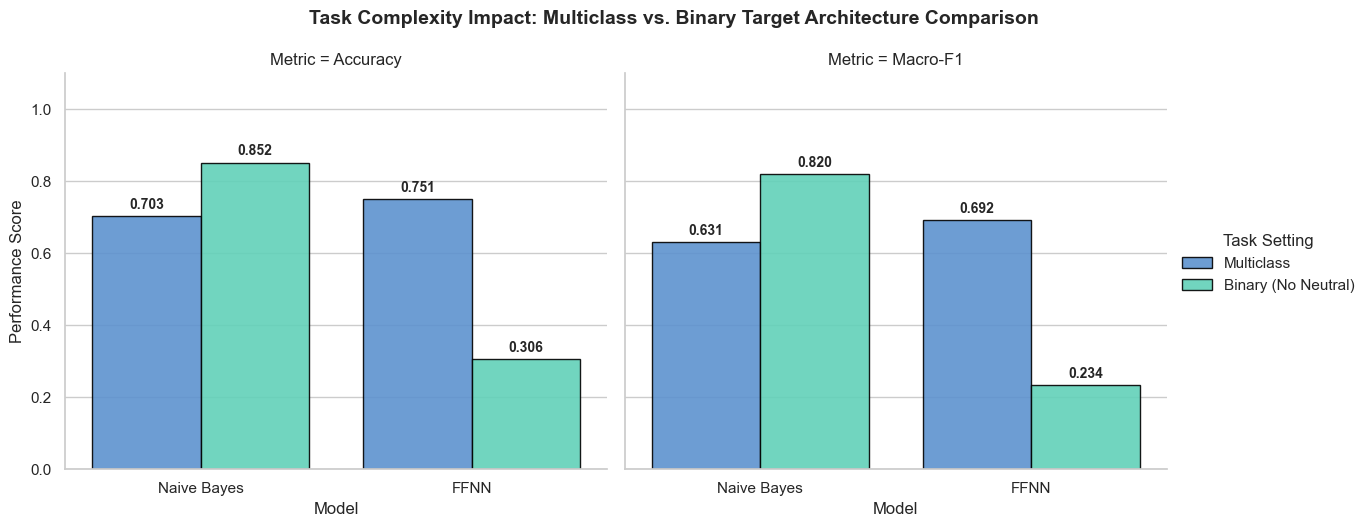


[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'

#############################################
--- TARGETED SYSTEMATIC SAMPLE ERRORS ---
#############################################

=============== MULTICLASS ERRORS ===============

Pipeline: Naive Bayes (BoW | (1, 3))
True Label:      [POSITIVE]
Predicted Label: [NEGATIVE]
Raw Input:       Vaisala also said it expects net sales of EUR 253.2 million for 2010 , compared with EUR 252.2 million recorded in 2009 .
Masked Tokens:   vaisala say expect net sale [MONEY] [DATE] , compare [MONEY] record [DATE] .
-----------------------------------------------------------------

Pipeline: FFNN (TF-IDF | (1, 2))
True Label:      [POSITIVE]
Predicted Label: [NEUTRAL]
Raw Input:       Aspocomp has repaid its interest bearing liability to Standard Chartered Bank and will use the rest of the consideration to partially repay its interest bearing liabilities in Finland and to improve its liquidity .
Masked Tokens:   asp

In [35]:
# ==========================================
# 6. ADVANCED ERROR ANALYSIS MODULE (PREP_MASKED ONLY: MULTICLASS VS. BINARY)
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

print("\n" + "="*50)
print("EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS")
print("="*50)

# 1. Define configurations using the exact global best hyperparameters
target_configs = [
    {
        "Model Name": "Naive Bayes",
        "Model": models.get("Naive Bayes") if "Naive Bayes" in models else MultinomialNB(),
        "Vectorizer": "BoW",
        "N-Gram": (1, 3),           # Corrected N-Gram
        "Sampler": SMOTE(random_state=42) # Dedicated Sampler
    },
    {
        "Model Name": "FFNN",
        "Vectorizer": "TF-IDF",
        "N-Gram": (1, 2),           # Corrected N-Gram
        "Sampler": TomekLinks(),    # Dedicated Sampler
        "Model_Init": lambda: PyTorchMLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            alpha=0.0001,
            batch_size=128,
            learning_rate_init=0.001,
            max_iter=50,
            random_state=42
        )
    }
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'
all_errors = []
performance_metrics = [] # <-- Stores metrics for visual tracking

if STRATEGY in df.columns:
    # -------------------------------------------------------------
    # SETUP 1: MULTICLASS DATASET (Original)
    # -------------------------------------------------------------
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)

    # -------------------------------------------------------------
    # SETUP 2: BINARY DATASET (Remove Neutral)
    # -------------------------------------------------------------
    neutral_idx = list(label_encoder.classes_).index('neutral')
    df_binary = df_multi[df_multi[TARGET_COL] != neutral_idx].copy().reset_index(drop=False)

    tasks = {
        "Multiclass": df_multi,
        "Binary (No Neutral)": df_binary
    }

    print(f"Base Checks -> Multiclass Samples: {len(df_multi)} | Binary Samples: {len(df_binary)}")
    print("-" * 70)

    for task_name, target_df in tasks.items():
        print(f"\n>>> Running Pipeline Evaluations for Task Domain: {task_name.upper()} <<<")

        for config in target_configs:
            model_label = f"{config['Model Name']} ({config['Vectorizer']} | {config['N-Gram']})"

            X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
                target_df[STRATEGY], target_df[TARGET_COL], target_df.index,
                test_size=0.20, random_state=42, stratify=target_df[TARGET_COL]
            )

            # Enforce max_features=5000 to match global configurations
            if config["Vectorizer"] == "BoW":
                vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern, max_features=5000)
            else:
                vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern, max_features=5000)

            X_train_vec = vect.fit_transform(X_train_raw)
            X_test_vec = vect.transform(X_test_raw)

            # Apply specifically mapped samplers
            sampler = config["Sampler"]
            if sampler is not None:
                X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)
            else:
                X_train_res, y_train_res = X_train_vec, y_train

            # Safely initialize models without resetting PyTorch architecture
            if config["Model Name"] == "FFNN":
                if 'set_reproducible_seeds' in globals():
                    set_reproducible_seeds(42)
                clf = config["Model_Init"]()
            else:
                clf = clone(config["Model"])

            clf.fit(X_train_res, y_train_res)
            y_pred = clf.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

            print(f" -> {config['Model Name']}: Test Accuracy = {acc:.4f} | Macro-F1 = {f1:.4f}")

            # Append results for chart extraction
            performance_metrics.append({
                "Task Setting": task_name,
                "Model": config['Model Name'],
                "Accuracy": acc,
                "Macro-F1": f1
            })

            errors_mask = y_test != y_pred

            if np.any(errors_mask):
                error_indices = idx_test[errors_mask]
                true_labels_text = label_encoder.inverse_transform(target_df.loc[error_indices, TARGET_COL])
                pred_labels_text = label_encoder.inverse_transform(y_pred[errors_mask])

                errors_df = pd.DataFrame({
                    'Task_Setting': task_name,
                    'Pipeline_Configuration': model_label,
                    'Original_Sentence': target_df.loc[error_indices, 'sentence'].values,
                    'Preprocessed_Text': target_df.loc[error_indices, STRATEGY].values,
                    'True_Label': true_labels_text,
                    'Predicted_Label': pred_labels_text
                })
                all_errors.append(errors_df)

    # -------------------------------------------------------------
    # NEW: GENERATE COMPARISON GRAPHIC
    # -------------------------------------------------------------
    metrics_df = pd.DataFrame(performance_metrics)
    melted_metrics = metrics_df.melt(id_vars=["Task Setting", "Model"], var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=melted_metrics,
        kind="bar",
        x="Model",
        y="Score",
        hue="Task Setting",
        col="Metric",
        palette={"Multiclass": "#4A90E2", "Binary (No Neutral)": "#50E3C2"},
        edgecolor="black",
        alpha=0.9,
        height=5,
        aspect=1.2
    )

    # Add numeric benchmarks on top of bars cleanly
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Performance Score")

    g.fig.suptitle("Task Complexity Impact: Multiclass vs. Binary Target Architecture Comparison", weight="bold", fontsize=14, y=1.05)
    plt.savefig("multiclass_vs_binary_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------------------------------------
    # EXPORT & DRILL-DOWN ANALYSIS REPORTING
    # -------------------------------------------------------------
    if all_errors:
        master_errors_df = pd.concat(all_errors, ignore_index=True)
        master_errors_df.to_csv("Misclassified_Samples_Log.csv", index=False, sep=";")
        print("\n" + "="*70)
        print("[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'")
        print("="*70)

        print("\n" + "#"*45 + "\n--- TARGETED SYSTEMATIC SAMPLE ERRORS ---\n" + "#"*45)

        for setting in ["Multiclass", "Binary (No Neutral)"]:
            print(f"\n" + "="*15 + f" {setting.upper()} ERRORS " + "="*15)
            setting_subset = master_errors_df[master_errors_df['Task_Setting'] == setting]

            for model_lbl in setting_subset['Pipeline_Configuration'].unique():
                final_subset = setting_subset[setting_subset['Pipeline_Configuration'] == model_lbl]

                if not final_subset.empty:
                    row = final_subset.sample(1, random_state=42).iloc[0]
                    print(f"\nPipeline: {row['Pipeline_Configuration']}")
                    print(f"True Label:      [{row['True_Label'].upper()}]")
                    print(f"Predicted Label: [{row['Predicted_Label'].upper()}]")
                    print(f"Raw Input:       {row['Original_Sentence']}")
                    print(f"Masked Tokens:   {row['Preprocessed_Text']}")
                    print("-" * 65)
    else:
        print("\n[!] Outstanding performance! Zero classification errors caught across test splits.")
else:
    print(f"Configuration Error: Preprocessing column '{STRATEGY}' missing from the root dataframe structure.")



EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS
Base Checks -> Multiclass Samples: 4797 | Binary Samples: 1950
----------------------------------------------------------------------

>>> Running Pipeline Evaluations for Task Domain: MULTICLASS <<<
 -> Naive Bayes: Test Accuracy = 0.7125 | Macro-F1 = 0.6341
 -> FFNN: Test Accuracy = 0.7417 | Macro-F1 = 0.6680

>>> Running Pipeline Evaluations for Task Domain: BINARY (NO NEUTRAL) <<<
 -> Naive Bayes: Test Accuracy = 0.8256 | Macro-F1 = 0.7934
 -> FFNN: Test Accuracy = 0.3051 | Macro-F1 = 0.2338


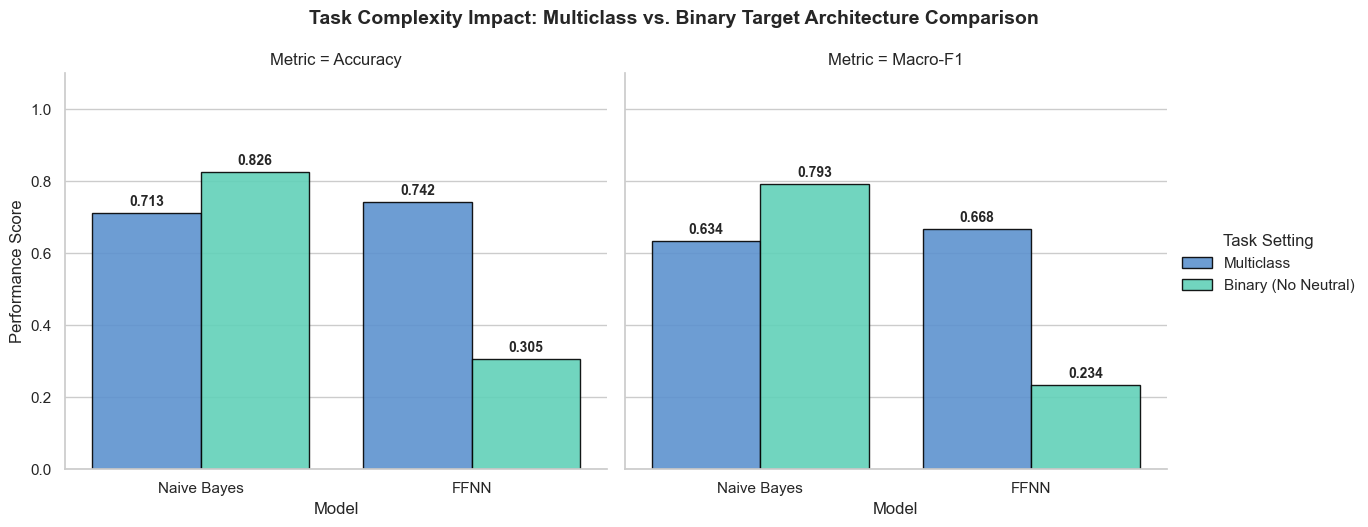


[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'

#############################################
--- TARGETED SYSTEMATIC SAMPLE ERRORS ---
#############################################

=============== MULTICLASS ERRORS ===============

Pipeline: Naive Bayes (BoW | (1, 4))
True Label:      [POSITIVE]
Predicted Label: [NEUTRAL]
Raw Input:       He believes that the soy-oats have a good chance of entering the UK market .
Masked Tokens:   believe soy-oats good chance enter uk market
-----------------------------------------------------------------

Pipeline: FFNN (TF-IDF | (1, 3))
True Label:      [NEUTRAL]
Predicted Label: [POSITIVE]
Raw Input:       When this investment is in place , Atria plans to expand into the Moscow market .
Masked Tokens:   investment place atrium plan expand moscow market
-----------------------------------------------------------------

=============== BINARY (NO NEUTRAL) ERRORS ===============

Pipeline: Naive Bayes (BoW | (1, 4))


In [ ]:
# ==========================================
# 6. ADVANCED ERROR ANALYSIS MODULE (PREP_MASKED ONLY: MULTICLASS VS. BINARY)
# ==========================================
print("\n" + "="*50)
print("EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS")
print("="*50)

target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 1)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'
all_errors = []
performance_metrics = [] # <-- Stores metrics for visual tracking

if STRATEGY in df.columns:
    # -------------------------------------------------------------
    # SETUP 1: MULTICLASS DATASET (Original)
    # -------------------------------------------------------------
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)

    # -------------------------------------------------------------
    # SETUP 2: BINARY DATASET (Remove Neutral)
    # -------------------------------------------------------------
    neutral_idx = list(label_encoder.classes_).index('neutral')
    df_binary = df_multi[df_multi[TARGET_COL] != neutral_idx].copy().reset_index(drop=False)

    tasks = {
        "Multiclass": df_multi,
        "Binary (No Neutral)": df_binary
    }

    print(f"Base Checks -> Multiclass Samples: {len(df_multi)} | Binary Samples: {len(df_binary)}")
    print("-" * 70)

    for task_name, target_df in tasks.items():
        print(f"\n>>> Running Pipeline Evaluations for Task Domain: {task_name.upper()} <<<")

        for config in target_configs:
            model_label = f"{config['Model Name']} ({config['Vectorizer']} | {config['N-Gram']})"

            X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
                target_df[STRATEGY], target_df[TARGET_COL], target_df.index,
                test_size=0.20, random_state=42, stratify=target_df[TARGET_COL]
            )

            if config["Vectorizer"] == "BoW":
                vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
            else:
                vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)

            X_train_vec = vect.fit_transform(X_train_raw)
            X_test_vec = vect.transform(X_test_raw)

            sampler = SMOTE(random_state=42)
            X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)

            clf = clone(config["Model"])
            clf.fit(X_train_res, y_train_res)
            y_pred = clf.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

            print(f" -> {config['Model Name']}: Test Accuracy = {acc:.4f} | Macro-F1 = {f1:.4f}")

            # Append results for chart extraction
            performance_metrics.append({
                "Task Setting": task_name,
                "Model": config['Model Name'],
                "Accuracy": acc,
                "Macro-F1": f1
            })

            errors_mask = y_test != y_pred

            if np.any(errors_mask):
                error_indices = idx_test[errors_mask]
                true_labels_text = label_encoder.inverse_transform(target_df.loc[error_indices, TARGET_COL])
                pred_labels_text = label_encoder.inverse_transform(y_pred[errors_mask])

                errors_df = pd.DataFrame({
                    'Task_Setting': task_name,
                    'Pipeline_Configuration': model_label,
                    'Original_Sentence': target_df.loc[error_indices, 'sentence'].values,
                    'Preprocessed_Text': target_df.loc[error_indices, STRATEGY].values,
                    'True_Label': true_labels_text,
                    'Predicted_Label': pred_labels_text
                })
                all_errors.append(errors_df)

    # -------------------------------------------------------------
    # NEW: GENERATE COMPARISON GRAPHIC
    # -------------------------------------------------------------
    metrics_df = pd.DataFrame(performance_metrics)
    melted_metrics = metrics_df.melt(id_vars=["Task Setting", "Model"], var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=melted_metrics,
        kind="bar",
        x="Model",
        y="Score",
        hue="Task Setting",
        col="Metric",
        palette={"Multiclass": "#4A90E2", "Binary (No Neutral)": "#50E3C2"},
        edgecolor="black",
        alpha=0.9,
        height=5,
        aspect=1.2
    )

    # Add numeric benchmarks on top of bars cleanly
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Performance Score")

    g.fig.suptitle("Task Complexity Impact: Multiclass vs. Binary Target Architecture Comparison", weight="bold", fontsize=14, y=1.05)
    plt.savefig("multiclass_vs_binary_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------------------------------------
    # EXPORT & DRILL-DOWN ANALYSIS REPORTING
    # -------------------------------------------------------------
    if all_errors:
        master_errors_df = pd.concat(all_errors, ignore_index=True)
        master_errors_df.to_csv("Misclassified_Samples_Log.csv", index=False, sep=";")
        print("\n" + "="*70)
        print("[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'")
        print("="*70)

        print("\n" + "#"*45 + "\n--- TARGETED SYSTEMATIC SAMPLE ERRORS ---\n" + "#"*45)

        for setting in ["Multiclass", "Binary (No Neutral)"]:
            print(f"\n" + "="*15 + f" {setting.upper()} ERRORS " + "="*15)
            setting_subset = master_errors_df[master_errors_df['Task_Setting'] == setting]

            for model_lbl in setting_subset['Pipeline_Configuration'].unique():
                final_subset = setting_subset[setting_subset['Pipeline_Configuration'] == model_lbl]

                if not final_subset.empty:
                    row = final_subset.sample(1, random_state=42).iloc[0]
                    print(f"\nPipeline: {row['Pipeline_Configuration']}")
                    print(f"True Label:      [{row['True_Label'].upper()}]")
                    print(f"Predicted Label: [{row['Predicted_Label'].upper()}]")
                    print(f"Raw Input:       {row['Original_Sentence']}")
                    print(f"Masked Tokens:   {row['Preprocessed_Text']}")
                    print("-" * 65)
    else:
        print("\n[!] Outstanding performance! Zero classification errors caught across test splits.")
else:
    print(f"Configuration Error: Preprocessing column '{STRATEGY}' missing from the root dataframe structure.")


In [150]:
# ==========================================
# 6. MULTICLASS EXCLUSIVE DISAGREEMENT & VISUALIZATION MODULE (4 EXAMPLES + SHORT SENTENCES + LATEX)
# ==========================================
print("\n" + "="*50)
print("EXECUTING MULTICLASS MODEL DISAGREEMENT ANALYSIS (4 EXAMPLES, <50 CHARS)")
print("="*50)

# --- Farbdefinitionen (nur für Symbole) ---
correct_color = "#2E8B57"  # Dunkleres Grün für ✅
incorrect_color = "#CD5C5C"  # Dunkleres Rot für ❌

target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 4)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'
all_preds_list = []

if STRATEGY in df.columns:
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)
    print(f"Total Multiclass Dataset Samples: {len(df_multi)}")
    print("-" * 70)

    # --- Modellvorhersagen berechnen ---
    for config in target_configs:
        model_label = config['Model Name']
        X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
            df_multi[STRATEGY], df_multi[TARGET_COL], df_multi.index,
            test_size=0.20, random_state=42, stratify=df_multi[TARGET_COL]
        )
        vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern) if config["Vectorizer"] == "BoW" else TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
        X_train_vec = vect.fit_transform(X_train_raw)
        X_test_vec = vect.transform(X_test_raw)
        sampler = SMOTE(random_state=42)
        X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)
        clf = clone(config["Model"])
        clf.fit(X_train_res, y_train_res)
        y_pred = clf.predict(X_test_vec)
        true_labels = label_encoder.inverse_transform(y_test)
        pred_labels = label_encoder.inverse_transform(y_pred)
        raw_sentences = df_multi.loc[idx_test, 'sentence'].values
        masked_sentences = df_multi.loc[idx_test, STRATEGY].values
        for src_text, mask_text, true_lbl, pred_lbl in zip(raw_sentences, masked_sentences, true_labels, pred_labels):
            all_preds_list.append({
                'Sentence': src_text,
                'Masked_Sentence': mask_text,
                'True Label': true_lbl,
                'Pipeline': model_label,
                'Prediction': pred_lbl
            })

    # --- Archetypen extrahieren ---
    preds_df = pd.DataFrame(all_preds_list)
    sentence_info = preds_df.drop_duplicates('Sentence')[['Sentence', 'True Label', 'Masked_Sentence']]
    p_pred = preds_df.pivot(index='Sentence', columns='Pipeline', values='Prediction').reset_index()
    p_pred = p_pred.merge(sentence_info, on='Sentence', how='left')
    p_pred = p_pred[p_pred['Sentence'].str.len() < 50].copy()

    # --- 4 spezifische Beispiele auswählen ---
    selected_rows = []

    # Archetyp 1: FFNN korrekt, Bayes falsch
    cond_1 = (p_pred['FFNN'] == p_pred['True Label']) & (p_pred['Naive Bayes'] != p_pred['True Label'])
    if cond_1.any():
        row = p_pred[cond_1].iloc[0].copy()
        row['Archetype'] = '1: FFNN Correct, NB Wrong'
        selected_rows.append(row)

    # Archetyp 2: FFNN falsch, Bayes korrekt
    cond_2 = (p_pred['FFNN'] != p_pred['True Label']) & (p_pred['Naive Bayes'] == p_pred['True Label'])
    if cond_2.any():
        row = p_pred[cond_2].iloc[0].copy()
        row['Archetype'] = '2: FFNN Wrong, NB Correct'
        selected_rows.append(row)

    # Archetyp 3: FFNN korrekt, Bayes falsch (2. Beispiel)
    if cond_1.sum() > 1:
        row = p_pred[cond_1].iloc[1].copy()
        row['Archetype'] = '3: FFNN Correct, NB Wrong (Alt)'
        selected_rows.append(row)
    elif cond_1.any():
        row = p_pred[cond_1].iloc[0].copy()
        row['Archetype'] = '3: FFNN Correct, NB Wrong (Alt)'
        selected_rows.append(row)

    # Archetyp 4: Beide falsch
    cond_4 = (p_pred['FFNN'] != p_pred['True Label']) & (p_pred['Naive Bayes'] != p_pred['True Label'])
    if cond_4.any():
        row = p_pred[cond_4].iloc[0].copy()
        row['Archetype'] = '4: Both Wrong'
        selected_rows.append(row)

    # --- Daten für die Tabelle vorbereiten ---
    viz_sample_pred = pd.DataFrame(selected_rows).reset_index(drop=True)
    display_df = viz_sample_pred.copy()

    # Kennzeichnung ohne Symbole
    for model in ['FFNN', 'Naive Bayes']:
        display_df[model] = display_df.apply(
            lambda row: f"{row[model]}" if row[model] == row['True Label'] else f"{row[model]}",
            axis=1
        )

    display_df['Sentence'] = display_df.apply(
        lambda row: f"\"{row['Sentence']}\" \\\\ \\textit{{\"Masked: {row['Masked_Sentence']}\"}}",
        axis=1
    )
    display_df['True Label'] = display_df['True Label'].str.upper()

    # --- LaTeX-Tabelle generieren ---
    latex_code = r"""\begin{table}[h]
\centering
\begin{tabular}{|p{8cm}|p{2cm}|p{2cm}|p{2cm}|}
\hline
\textbf{Sentence} & \textbf{True Label} & \textbf{FFNN Prediction} & \textbf{Naive Bayes Pred.}  \\ \hline
"""

    for _, row in display_df.iterrows():
        latex_code += f"{row['Sentence']} & {row['True Label'].lower()} & {row['FFNN']} & {row['Naive Bayes']}  \\\\ \\hline\n"

    latex_code += r"""\end{tabular}
\end{table}"""

    print("\n--- Clean LaTeX Code ---\n")
    print(latex_code)



EXECUTING MULTICLASS MODEL DISAGREEMENT ANALYSIS (4 EXAMPLES, <50 CHARS)
Total Multiclass Dataset Samples: 4752
----------------------------------------------------------------------

--- Clean LaTeX Code ---

\begin{table}[h]
\centering
\begin{tabular}{|p{8cm}|p{2cm}|p{2cm}|p{2cm}|}
\hline
\textbf{Sentence} & \textbf{True Label} & \textbf{FFNN Prediction} & \textbf{Naive Bayes Pred.}  \\ \hline
"Earnings per share EPS amounted to EUR0 .01 ." \\ \textit{"Masked: earnings share eps amount [MONEY] ."} & neutral & neutral & negative  \\ \hline
"Europe needs 17 new large paper machines ." \\ \textit{"Masked: europe need [NUMBER] new large paper machine"} & neutral & positive & neutral  \\ \hline
"In beers , Olvi retained its market position ." \\ \textit{"Masked: beer olvi retain market position"} & neutral & neutral & positive  \\ \hline
"Gearing was 43 % compared to 67 % in 2004 ." \\ \textit{"Masked: gearing [PERCENT] compare [PERCENT] [DATE] ."} & neutral & positive & negative  \\ \hl

In [ ]:
pip install tabulate


  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
